# Segmenting Touching Nuclei - a challenge for ML models?
We saw previously that segmenting touching nuclei is difficult with scikit-image. The method consistently underestimates how many nuclei there are because it struggles to split touching nuclei.

Classical segmentation often breaks down when nuclei touch or vary in shape, so ML models are used because they learn from examples rather than relying on fixed rules. The most widely used architecture in biomedical imaging is U‑Net, which produces pixel‑wise masks and can be trained on relatively small datasets with augmentation. It’s good for semantic segmentation — deciding which pixels belong to “nucleus” vs “background.”

If you need to distinguish individual nuclei, especially in crowded regions, Mask R‑CNN is designed for instance segmentation: it detects each object and outputs a separate mask. This makes it stronger at untangling clusters, though it requires more data and compute.

For quick results without training, Cellpose is a pretrained model built specifically for cells and nuclei. It handles both round and elongated shapes and often works out‑of‑the‑box. A hybrid approach is also common: for example, using a CNN to generate probability maps and then applying watershed to split touching nuclei.

In practice, the choice depends on your goals. If you want a fast result, Cellpose is the easiest entry point. If you have labeled masks, you can train U‑Net models. If the focus is on separating crowded nuclei into distinct objects, Mask R‑CNN or a hybrid pipeline is worth trying.

Here, we start with cellpose. This notebook (everything below) is lifted directly from the [github](https://github.com/MouseLand/cellpose).

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

Check GPU and instantiate model - will download weights.

In [29]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
# if core.use_gpu()==False:
#   raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=False) # needs CUDA GPU to run on GPU

### set a couple of parameters
downscale_factor = 0.2  # downscale factor for faster processing
num_images = 20  # number of images to process
diameter = 30 # diameter in pixels. if None, it will be estimated

creating new log file
2025-12-02 10:27:59,466 [INFO] WRITING LOG OUTPUT TO C:\Users\ucsagil\.cellpose\run.log
2025-12-02 10:27:59,467 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.13.9 
torch version:  	2.9.1
2025-12-02 10:27:59,468 [INFO] >>>> using CPU
2025-12-02 10:27:59,469 [INFO] >>>> using CPU
2025-12-02 10:28:00,812 [INFO] >>>> loading model C:\Users\ucsagil\.cellpose\models\cpsam


Input directory with your images:

In [30]:
## set dirs
cwd = Path.cwd()
# Find the first parent that matches the target folder
for p in cwd.parents:
    if p.name == "UCL-Biosciences-Image-Analysis":
        REPO_DIR = p
        break
else:
    raise FileNotFoundError("Base directory 'UCL-Biosciences-Image-Analysis' not found in path.")

dir = REPO_DIR / "input_data" / "BBBC006_v1_images_z_16"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

out_dir = REPO_DIR / "output" / "cellpose_results"
out_dir.mkdir(parents=True, exist_ok=True)

# *** change to your image extension ***
image_ext = "*_w1*.tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])[:num_images]

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

20 images in folder:
mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4e11-8762-62b5d2b86216.tif
mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-468b-bb15-d55443c280d9.tif
mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4999-9f72-ee77bfdac65f.tif
mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4bd6-bc83-0109953e7760.tif
mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4a07-9288-cc44b68c37b7.tif
mcf-z-stacks-03212011_a03_s2_w1b9a28dd8-a2b3-48e2-840a-b5d72cb75c88.tif
mcf-z-stacks-03212011_a04_s1_w1659bc45b-7df7-41ea-9b6d-df2e251b1cc4.tif
mcf-z-stacks-03212011_a04_s2_w18d3948e6-777b-41c4-8ed4-fd0b82a767a4.tif
mcf-z-stacks-03212011_a05_s1_w172e356dd-2e65-4303-9992-1747045f13ee.tif
mcf-z-stacks-03212011_a05_s2_w17b15d100-511d-4121-b7fd-039db5767f79.tif
mcf-z-stacks-03212011_a06_s1_w12494d2f0-673e-4a15-aa25-91eaaf719526.tif
mcf-z-stacks-03212011_a06_s2_w10c0ccfa4-227f-42b6-b055-e38489fc81be.tif
mcf-z-stacks-03212011_a07_s1_w13bc4e736-d5ee-40bb-86ac-3ab5940ff031.tif
mcf-z-stacks-03212011_a07_s2_w18b191625-ed9

## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



your image has shape: (208, 278). Assuming channel dimension is last with 278 channels


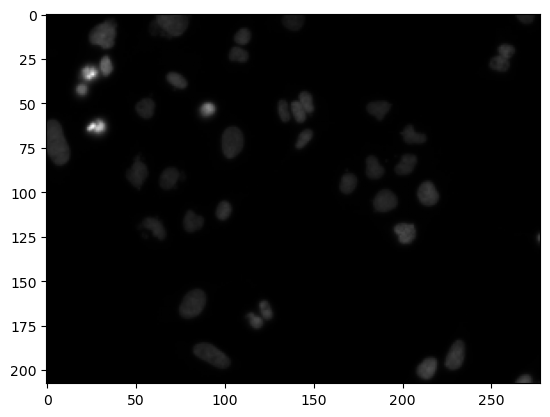

In [31]:
img = io.imread(files[9])

## take too long on laptop. downscale first
from skimage.transform import rescale

# Downscale by 0.5 in each dimension (adjust factor as needed)
img = rescale(img, 0.4, anti_aliasing=True, preserve_range=True)


print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')
# have a look at the image to see if we have downscaled correctly. nuclei should be visible and distinguishable
plt.imshow(img, cmap='gray')

### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [32]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

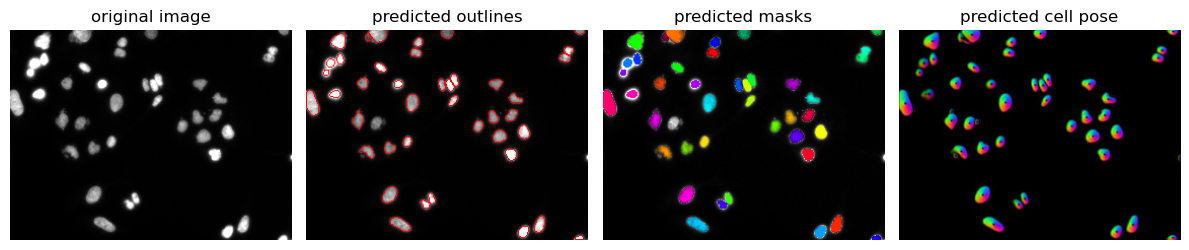

In [33]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels = img   # now shape (Y, X, 1) as only one channel

flow_threshold = 0.5 # pixels get a flow error score, cells with score below this are removed. Higher threshold = fewer cells
cellprob_threshold = 0.0 # probability threshold for a pixel belonging to a cell. Higher threshold = smaller, more confident
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold,
                                  cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


In [34]:
## looks promising
# now run on all images and store results in df
results = []

for i in trange(len(files)):
    print(f'Processing image {i+1}/{len(files)}: {files[i].name}')
    img = io.imread(files[i])
    
    # Downscale by 0.5 in each dimension (adjust factor as needed)
    img = rescale(img, downscale_factor, anti_aliasing=True, preserve_range=True)
    
    img_selected_channels = np.zeros_like(img)
    img_selected_channels = img   # now shape (Y, X, 1) as only one channel
    
    masks, flows, styles = model.eval(img_selected_channels,
                                    #    batch_size=32, # gpu only
                                       flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                        normalize={"tile_norm_blocksize": tile_norm_blocksize},
                                        diameter = diameter)
    
    # save masks
    io.imsave(out_dir / f"{files[i].stem}_downscaleFactor{downscale_factor}_masks.tif", masks.astype(np.uint16))
    
    n_cells = np.max(masks)
    results.append({
        "filename": files[i].name,
        "n_cells": n_cells
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)



  0%|          | 0/20 [00:00<?, ?it/s]

Processing image 1/20: mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4e11-8762-62b5d2b86216.tif


  5%|▌         | 1/20 [01:55<36:37, 115.65s/it]

Processing image 2/20: mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-468b-bb15-d55443c280d9.tif


 10%|█         | 2/20 [04:08<37:41, 125.62s/it]

...

Processing image 19/20: mcf-z-stacks-03212011_a10_s1_w156636015-b90a-4755-b5e9-4ad5c11a244a.tif


 95%|█████████▌| 19/20 [37:57<01:54, 114.45s/it]

Processing image 20/20: mcf-z-stacks-03212011_a10_s2_w1892c2650-bdc9-4a35-b3a3-082eab4aed84.tif


100%|██████████| 20/20 [39:59<00:00, 119.99s/it]

                                             filename  n_cells
0   mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...        7
1   mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...       23
2   mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...       60
3   mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...       80
4   mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...       10
5   mcf-z-stacks-03212011_a03_s2_w1b9a28dd8-a2b3-4...        9
6   mcf-z-stacks-03212011_a04_s1_w1659bc45b-7df7-4...       93
7   mcf-z-stacks-03212011_a04_s2_w18d3948e6-777b-4...       40
8   mcf-z-stacks-03212011_a05_s1_w172e356dd-2e65-4...       40
9   mcf-z-stacks-03212011_a05_s2_w17b15d100-511d-4...       36
10  mcf-z-stacks-03212011_a06_s1_w12494d2f0-673e-4...      112
11  mcf-z-stacks-03212011_a06_s2_w10c0ccfa4-227f-4...       95
12  mcf-z-stacks-03212011_a07_s1_w13bc4e736-d5ee-4...       50
13  mcf-z-stacks-03212011_a07_s2_w18b191625-ed9c-4...       58
14  mcf-z-stacks-03212011_a08_s1_w1648330db-f2a7-4...  

In [35]:
### merge with previous counts
results_df.rename(columns={"n_cells": "cellpose_count",
                           'filename' : 'file'}, inplace=True)

previous_counts_file = REPO_DIR / "output" / "BBBC006_nuclei_counts_comparison.csv"
previous_counts_df = pd.read_csv(previous_counts_file)

merged_df = previous_counts_df.merge(results_df, on='file', how='left')

merged_df.head()


,file,skimage_count,ground_truth_count,cellpose_count
0,mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...,6,8,7.0
1,mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...,4,21,23.0
2,mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...,50,67,60.0
3,mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...,65,80,80.0
4,mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...,9,10,10.0


c:\Users\ucsagil\OneDrive - University College London\Development\cellpose\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 80 rows containing missing values.


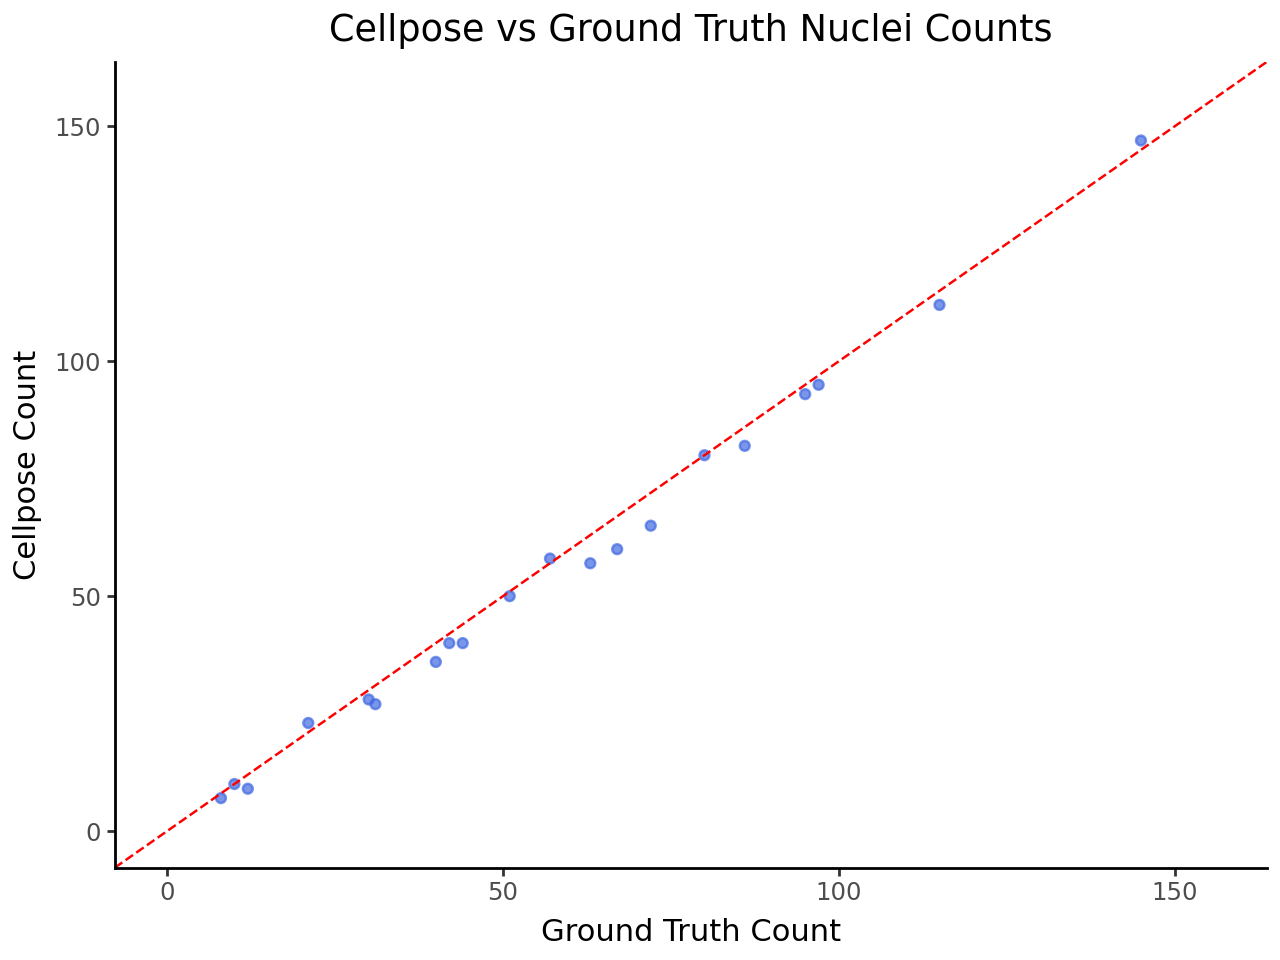

In [36]:
### show plots
import plotnine as p9
(
    p9.ggplot(merged_df, p9.aes(x='ground_truth_count', y='cellpose_count')) +
    p9.geom_point(colour = "royalblue", alpha = 0.7) +
    p9.theme_classic() +
    p9.geom_abline(slope=1, intercept=0, linetype='dashed', color='red') +
    p9.labs(x='Ground Truth Count', y='Cellpose Count', title='Cellpose vs Ground Truth Nuclei Counts') +
    p9.lims(x=(0, merged_df['ground_truth_count'].max()), y=(0, merged_df['ground_truth_count'].max()))

)



In [37]:
### and quickly show the error
## skimage was ~23%

# absolute value of the difference between estimated and ground truth counts
# divided by ground truth count to get percentage error
# then divide by number of images to get average error (and SD)
merged_df['abs_error'] = np.abs(merged_df['cellpose_count'] - merged_df['ground_truth_count'])
merged_df['pct_error'] = merged_df['abs_error'] / merged_df['ground_truth_count'] * 100
mean_error = merged_df['pct_error'].mean()
std_error = merged_df['pct_error'].std()
print(f"Average Percentage Error: {mean_error:.2f}% ± {std_error:.2f}%")

Average Percentage Error: 6.83% ± 6.05%


## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [38]:
# masks_ext = ".png" if image_ext == ".png" else ".tif"
# for i in trange(len(files)):
#     f = files[i]
#     # img = io.imread(f)
#     masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
#                                   normalize={"tile_norm_blocksize": tile_norm_blocksize})
#     io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [39]:
# print("loading images")
# imgs = [io.imread(files[i]) for i in trange(len(files))]

# print("running cellpose-SAM")
# masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
#                                   normalize={"tile_norm_blocksize": tile_norm_blocksize})

# print("saving masks")
# for i in trange(len(files)):
#     f = files[i]
#     io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [40]:
# for i in trange(len(files)):
#     f = files[i]
#     masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
#     io.save_rois(masks0, f)